In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!") 

Libraries imported successfully!


In [8]:
import pandas as pd

customer_df = pd.read_csv("data/customer_churn.csv")
property_df = pd.read_csv("data/house_prices.csv")
sales_df = pd.read_csv("data/sales_data.csv")

print("Customer dataset:", customer_df.shape)
print("Property dataset:", property_df.shape)
print("Sales dataset:", sales_df.shape)

Customer dataset: (500, 9)
Property dataset: (300, 8)
Sales dataset: (100, 7)


In [6]:
import os
print(os.getcwd())

C:\Users\Rutuja\OneDrive\Documents\Complete-Business-Analysis


In [7]:
import os

print(os.listdir())
print(os.listdir("data"))

['.ipynb_checkpoints', 'business_analysis.ipynb', 'data', 'report', 'visualizations']
['.ipynb_checkpoints', 'customer_churn.csv', 'house_prices.csv', 'sales_data.csv']


In [9]:
customer_df.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [10]:
property_df.head()
   

,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000


In [11]:
sales_df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [12]:
#Customer dataset 
customer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   CustomerID        500 non-null    str  
 1   Tenure            500 non-null    int64
 2   MonthlyCharges    500 non-null    int64
 3   TotalCharges      500 non-null    int64
 4   Contract          500 non-null    str  
 5   PaymentMethod     500 non-null    str  
 6   PaperlessBilling  500 non-null    str  
 7   SeniorCitizen     500 non-null    int64
 8   Churn             500 non-null    int64
dtypes: int64(5), str(4)
memory usage: 50.8 KB


In [13]:
customer_df.isnull().sum()

CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

In [14]:
print("Duplicate rows:", customer_df.duplicated().sum())
print("Duplicate Customer IDs:", customer_df["CustomerID"].duplicated().sum())

Duplicate rows: 0
Duplicate Customer IDs: 0


In [15]:
customer_df.describe()

,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,36.532000,113.636000,4237.882000,0.498000,0.106000
std,20.667057,51.799903,2260.619837,0.500497,0.308146
min,1.000000,20.000000,159.000000,0.000000,0.000000
25%,19.000000,67.000000,2237.250000,0.000000,0.000000
50%,37.000000,115.000000,4182.500000,0.000000,0.000000
75%,54.000000,158.000000,6266.750000,1.000000,0.000000
max,71.000000,199.000000,7992.000000,1.000000,1.000000


In [16]:
#Property dataset
property_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Property_ID    300 non-null    str  
 1   Area           300 non-null    int64
 2   Bedrooms       300 non-null    int64
 3   Bathrooms      300 non-null    int64
 4   Age            300 non-null    int64
 5   Location       300 non-null    str  
 6   Property_Type  300 non-null    str  
 7   Price          300 non-null    int64
dtypes: int64(5), str(3)
memory usage: 25.2 KB


In [17]:
property_df.isnull().sum()

Property_ID      0
Area             0
Bedrooms         0
Bathrooms        0
Age              0
Location         0
Property_Type    0
Price            0
dtype: int64

In [18]:
print("Duplicate rows:", property_df.duplicated().sum())
print("Duplicate Property IDs:", property_df["Property_ID"].duplicated().sum())

Duplicate rows: 0
Duplicate Property IDs: 0


In [19]:
property_df.describe()

,Area,Bedrooms,Bathrooms,Age,Price
count,300.00000,300.000000,300.000000,300.000000,3.000000e+02
mean,2759.70000,3.033333,2.026667,25.000000,2.488366e+07
std,1297.68143,1.467219,0.792495,14.332646,1.266525e+07
min,520.00000,1.000000,1.000000,0.000000,3.695000e+06
25%,1675.75000,2.000000,1.000000,12.000000,1.527750e+07
50%,2738.00000,3.000000,2.000000,25.500000,2.236500e+07
75%,3801.25000,4.000000,3.000000,36.250000,3.460812e+07
max,4999.00000,5.000000,3.000000,49.000000,5.870000e+07


In [20]:
#Sales dataset
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Date         100 non-null    str  
 1   Product      100 non-null    str  
 2   Quantity     100 non-null    int64
 3   Price        100 non-null    int64
 4   Customer_ID  100 non-null    str  
 5   Region       100 non-null    str  
 6   Total_Sales  100 non-null    int64
dtypes: int64(3), str(4)
memory usage: 8.3 KB


In [21]:
sales_df.isnull().sum()

Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

In [22]:
print("Duplicate rows:", sales_df.duplicated().sum())
print("Duplicate Customer IDs:", sales_df["Customer_ID"].duplicated().sum())

Duplicate rows: 0
Duplicate Customer IDs: 0


In [23]:
sales_df.describe()


,Quantity,Price,Total_Sales
count,100.000000,100.000000,100.000000
mean,4.780000,25808.510000,123650.480000
std,2.588163,13917.630242,100161.085275
min,1.000000,1308.000000,6540.000000
25%,2.750000,14965.250000,39517.500000
50%,5.000000,24192.000000,97955.500000
75%,7.000000,38682.250000,175792.500000
max,9.000000,49930.000000,373932.000000


In [24]:
print(sales_df["Date"].head(10))
print(sales_df["Date"].dtype)

0    2024-01-01
1    2024-01-02
2    2024-01-03
3    2024-01-04
4    2024-01-05
5    2024-01-06
6    2024-01-07
7    2024-01-08
8    2024-01-09
9    2024-01-10
Name: Date, dtype: str
str


In [25]:
customer_clean = customer_df.copy()
property_clean = property_df.copy()
sales_clean = sales_df.copy()

In [26]:
customer_clean["Tenure"] = pd.to_numeric(customer_clean["Tenure"], errors="coerce")
customer_clean["MonthlyCharges"] = pd.to_numeric(customer_clean["MonthlyCharges"], errors="coerce")
customer_clean["TotalCharges"] = pd.to_numeric(customer_clean["TotalCharges"], errors="coerce")

property_clean["Area"] = pd.to_numeric(property_clean["Area"], errors="coerce")
property_clean["Bedrooms"] = pd.to_numeric(property_clean["Bedrooms"], errors="coerce")
property_clean["Bathrooms"] = pd.to_numeric(property_clean["Bathrooms"], errors="coerce")
property_clean["Age"] = pd.to_numeric(property_clean["Age"], errors="coerce")
property_clean["Price"] = pd.to_numeric(property_clean["Price"], errors="coerce")

sales_clean["Quantity"] = pd.to_numeric(sales_clean["Quantity"], errors="coerce")
sales_clean["Price"] = pd.to_numeric(sales_clean["Price"], errors="coerce")
sales_clean["Total_Sales"] = pd.to_numeric(sales_clean["Total_Sales"], errors="coerce")

In [27]:
print("Customer missing values:")
print(customer_clean.isnull().sum())

print("\nProperty missing values:")
print(property_clean.isnull().sum())

print("\nSales missing values:")
print(sales_clean.isnull().sum())

Customer missing values:
CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

Property missing values:
Property_ID      0
Area             0
Bedrooms         0
Bathrooms        0
Age              0
Location         0
Property_Type    0
Price            0
dtype: int64

Sales missing values:
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64


In [28]:
customer_clean.to_csv("data/cleaned_customer_churn.csv", index=False)
property_clean.to_csv("data/cleaned_property_data.csv", index=False)
sales_clean.to_csv("data/cleaned_sales_data.csv", index=False)

print("Cleaned datasets saved successfully!")

Cleaned datasets saved successfully!


In [29]:
churn_counts = customer_clean["Churn"].value_counts()

print(churn_counts)

churn_rate = customer_clean["Churn"].mean() * 100

print(f"Overall Churn Rate: {churn_rate:.2f}%")

Churn
0    447
1     53
Name: count, dtype: int64
Overall Churn Rate: 10.60%


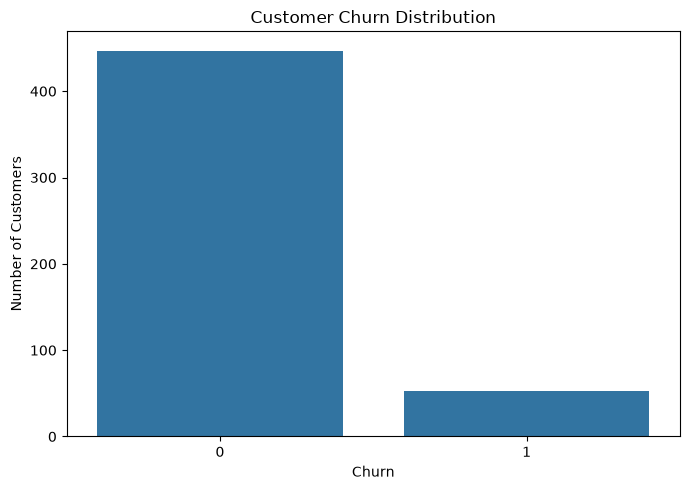

In [30]:
plt.figure(figsize=(7,5))

sns.countplot(data=customer_clean, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("visualizations/customer_churn_distribution.png", dpi=300)
plt.show()

In [31]:
contract_churn = pd.crosstab(
    customer_clean["Contract"],
    customer_clean["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                   0          1
Contract                            
Month-to-month  79.411765  20.588235
One year        95.698925   4.301075
Two year        93.055556   6.944444


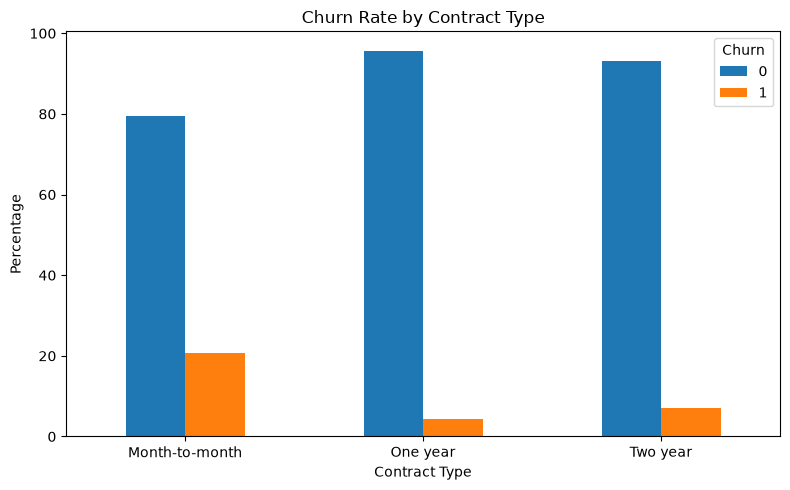

In [32]:
contract_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "visualizations/churn_by_contract.png",
    dpi=300
)

plt.show()

In [33]:
payment_churn = pd.crosstab(
    customer_clean["PaymentMethod"],
    customer_clean["Churn"],
    normalize="index"
) * 100

print(payment_churn)


Churn                     0          1
PaymentMethod                         
Bank Transfer     93.081761   6.918239
Credit Card       86.516854  13.483146
Electronic Check  88.957055  11.042945


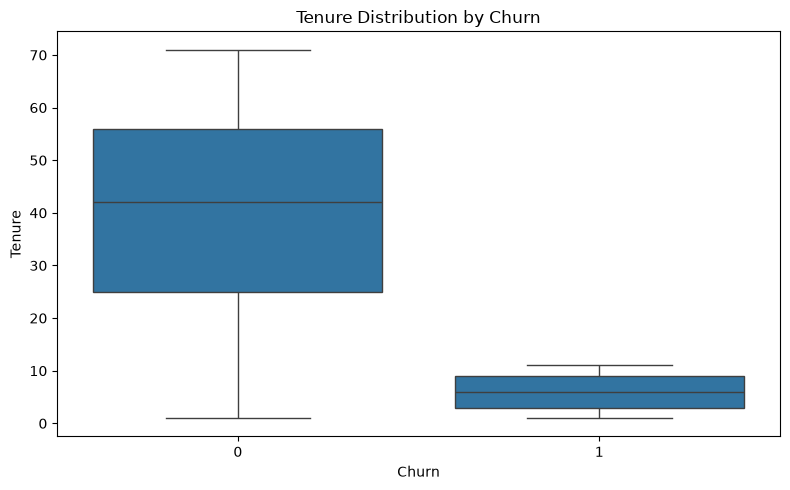

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=customer_clean,
    x="Churn",
    y="Tenure"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")

plt.tight_layout()

plt.savefig(
    "visualizations/tenure_vs_churn.png",
    dpi=300
)

plt.show()


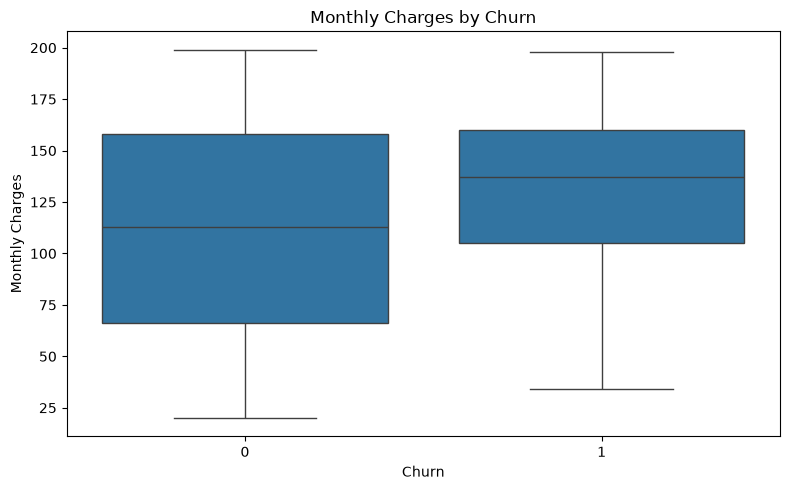

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=customer_clean,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()

plt.savefig(
    "visualizations/monthly_charges_vs_churn.png",
    dpi=300
)

plt.show()

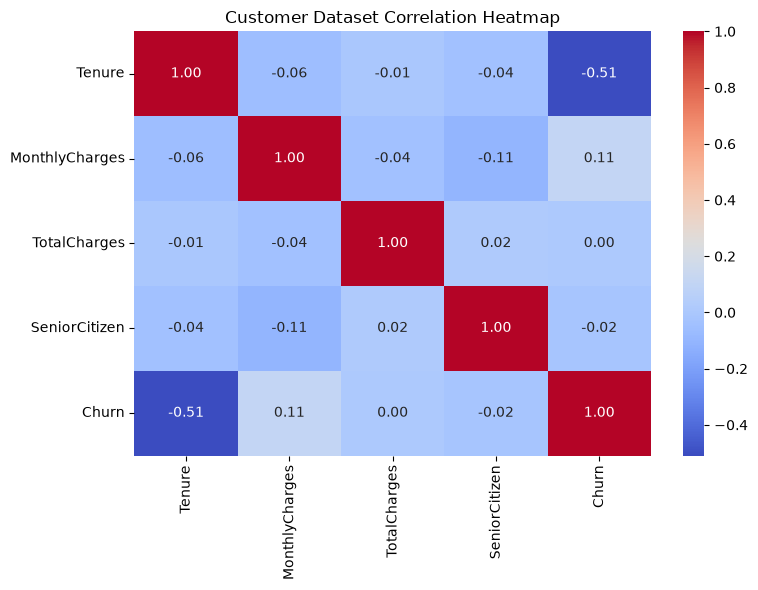

In [36]:
plt.figure(figsize=(8,6))

numeric_customer = customer_clean[
    ["Tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn"]
]

sns.heatmap(
    numeric_customer.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Customer Dataset Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "visualizations/customer_correlation_heatmap.png",
    dpi=300
)

plt.show()

In [37]:
property_clean.groupby("Location")["Price"].mean().sort_values(ascending=False)

Location
City Center    3.314979e+07
Suburb         2.510807e+07
Rural          1.646143e+07
Name: Price, dtype: float64

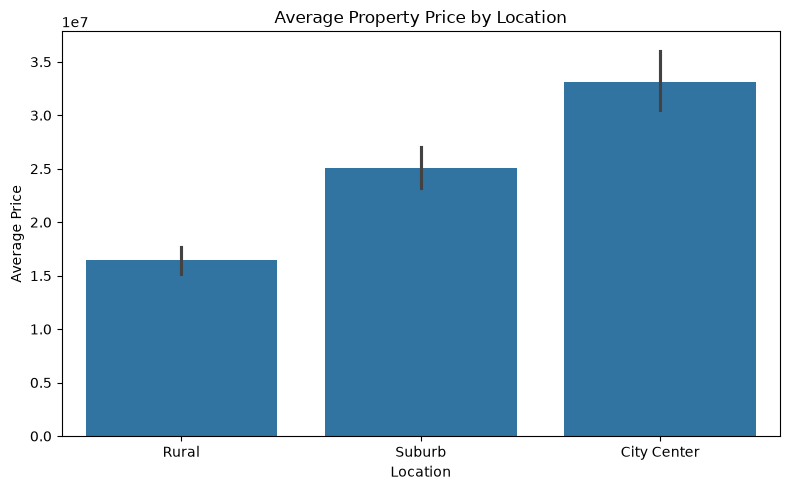

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=property_clean,
    x="Location",
    y="Price"
)

plt.title("Average Property Price by Location")
plt.xlabel("Location")
plt.ylabel("Average Price")

plt.tight_layout()

plt.savefig(
    "visualizations/property_price_by_location.png",
    dpi=300
)

plt.show()

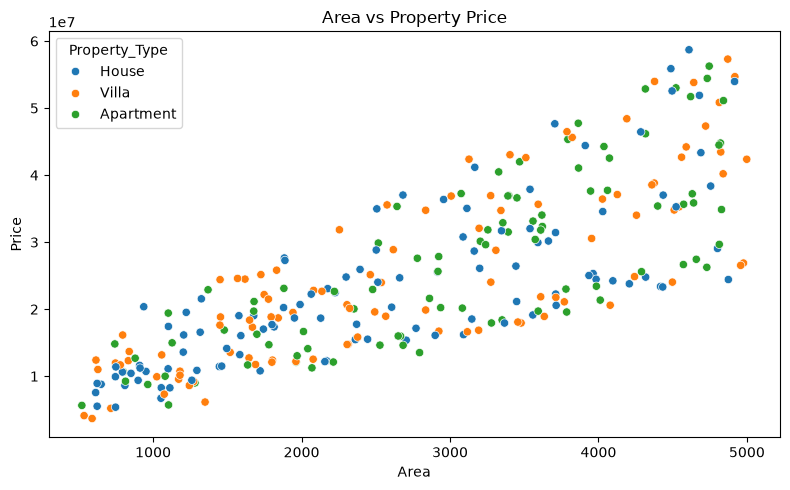

In [39]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=property_clean,
    x="Area",
    y="Price",
    hue="Property_Type"
)

plt.title("Area vs Property Price")
plt.xlabel("Area")
plt.ylabel("Price")

plt.tight_layout()

plt.savefig(
    "visualizations/area_vs_price.png",
    dpi=300
)

plt.show()

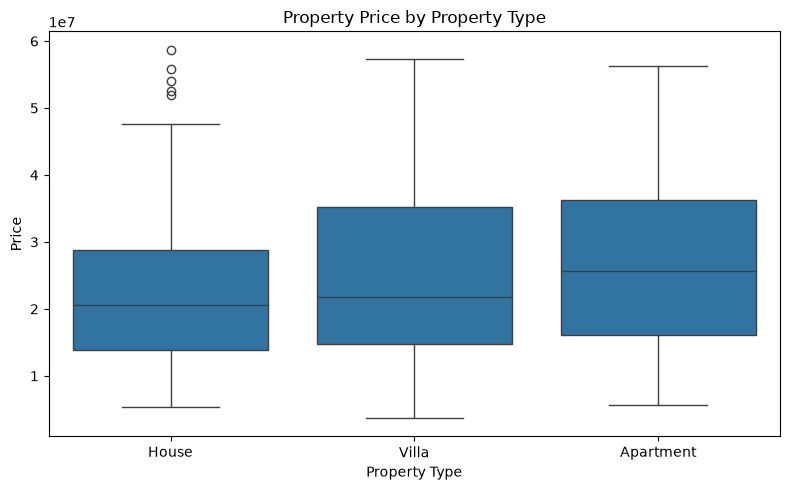

In [40]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=property_clean,
    x="Property_Type",
    y="Price"
)

plt.title("Property Price by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Price")

plt.tight_layout()

plt.savefig(
    "visualizations/price_by_property_type.png",
    dpi=300
)

plt.show()

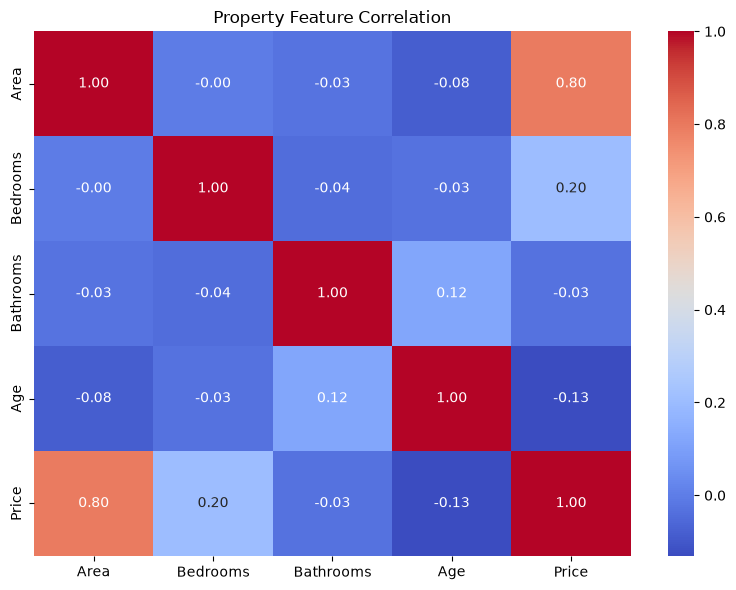

In [41]:
plt.figure(figsize=(8,6))

property_numeric = property_clean[
    ["Area", "Bedrooms", "Bathrooms", "Age", "Price"]
]

sns.heatmap(
    property_numeric.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Property Feature Correlation")

plt.tight_layout()

plt.savefig(
    "visualizations/property_correlation_heatmap.png",
    dpi=300
)

plt.show()

In [42]:
print("Total Sales:", sales_clean["Total_Sales"].sum())
print("Average Transaction Sales:", sales_clean["Total_Sales"].mean())
print("Total Quantity Sold:", sales_clean["Quantity"].sum())

Total Sales: 12365048
Average Transaction Sales: 123650.48
Total Quantity Sold: 478


In [43]:
product_sales = sales_clean.groupby(
    "Product"
)["Total_Sales"].sum().sort_values(ascending=False)

print(product_sales)

Product
Laptop        3889210
Tablet        2884340
Phone         2859394
Headphones    1384033
Monitor       1348071
Name: Total_Sales, dtype: int64


In [44]:
region_sales = sales_clean.groupby(
    "Region"
)["Total_Sales"].sum().sort_values(ascending=False)

print(region_sales)

Region
North    3983635
South    3737852
East     2519639
West     2123922
Name: Total_Sales, dtype: int64


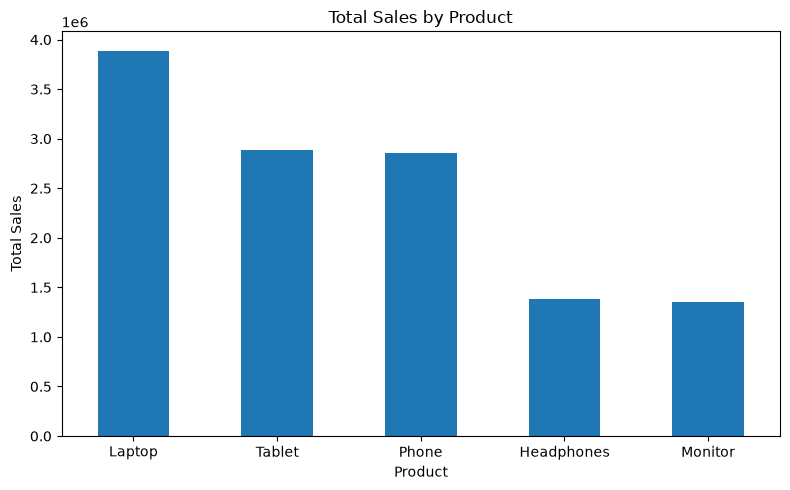

In [45]:
plt.figure(figsize=(8,5))

product_sales.plot(kind="bar")

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "visualizations/sales_by_product.png",
    dpi=300
)

plt.show()

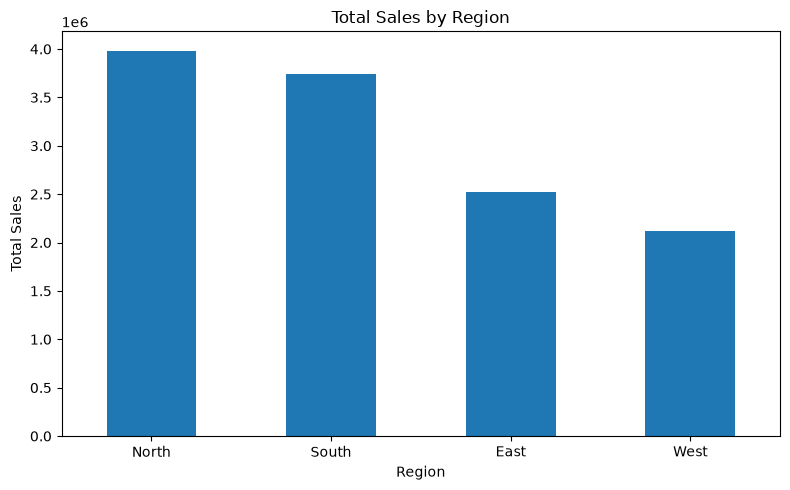

In [46]:
plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "visualizations/sales_by_region.png",
    dpi=300
)

plt.show()

In [47]:
# Hypothesis 1: Monthly charges and churn
churned = customer_clean[
    customer_clean["Churn"] == 1
]["MonthlyCharges"]

retained = customer_clean[
    customer_clean["Churn"] == 0
]["MonthlyCharges"]

t_stat, p_value = stats.ttest_ind(
    churned,
    retained,
    equal_var=False
)

print("Welch's t-test")
print("t-statistic:", t_stat)
print("p-value:", p_value)

Welch's t-test
t-statistic: 2.646439327283195
p-value: 0.010079197699533072


In [48]:
#Hypothesis 2: Contract and churn
contract_table = pd.crosstab(
    customer_clean["Contract"],
    customer_clean["Churn"]
)

chi2, p_value, dof, expected = stats.chi2_contingency(
    contract_table
)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 27.715301368568205
p-value: 9.587354270923881e-07


In [49]:
X = customer_clean[
    [
        "Tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract",
        "PaymentMethod",
        "PaperlessBilling",
        "SeniorCitizen"
    ]
]

y = customer_clean["Churn"]

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Contract",
    "PaymentMethod",
    "PaperlessBilling"
]

numeric_features = [
    "Tenure",
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [53]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Tenure','MonthlyCharges','TotalCharges',...,'PaymentMethod', 'PaperlessBilling','SeniorCitizen']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``r

In [54]:
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions:", y_pred[:10])
print("Probabilities:", y_prob[:10])

Predictions: [0 0 0 0 0 0 0 0 0 0]
Probabilities: [3.41628391e-06 6.90936669e-02 1.88920067e-08 2.73268026e-01
 1.33412708e-08 3.18389252e-10 4.41860038e-01 2.07980180e-01
 2.81544108e-06 6.96825519e-08]


In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")
print(f"ROC-AUC  : {roc_auc:.3f}")

Logistic Regression Performance
--------------------------------
Accuracy : 0.930
Precision: 0.750
Recall   : 0.545
F1 Score : 0.632
ROC-AUC  : 0.982


Confusion Matrix:
[[87  2]
 [ 5  6]]


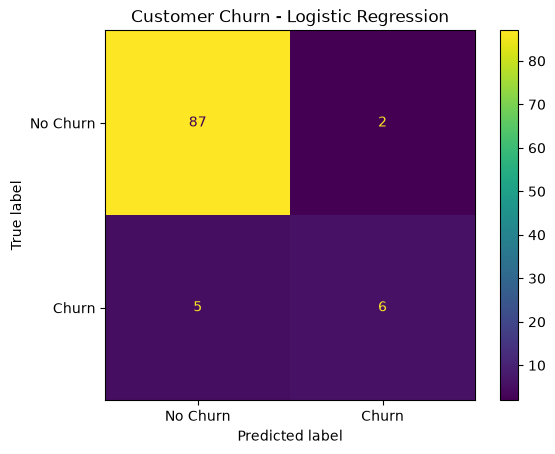

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Customer Churn - Logistic Regression")
plt.show()

Confusion Matrix:
[[87  2]
 [ 5  6]]


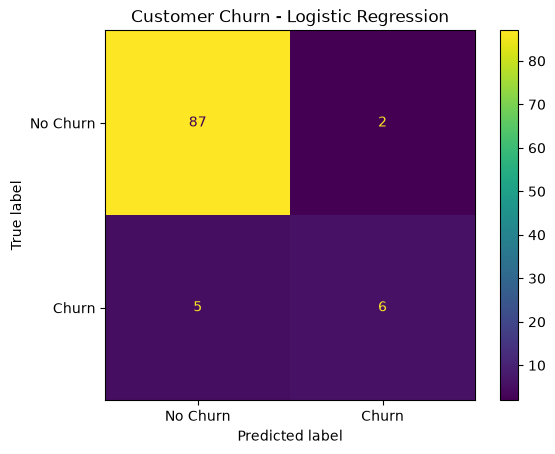

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Customer Churn - Logistic Regression")
plt.show()

In [58]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"],
    zero_division=0
))

              precision    recall  f1-score   support

    No Churn       0.95      0.98      0.96        89
       Churn       0.75      0.55      0.63        11

    accuracy                           0.93       100
   macro avg       0.85      0.76      0.80       100
weighted avg       0.92      0.93      0.93       100



### Logistic Regression Results

A logistic regression model was developed to predict customer churn using
Tenure, MonthlyCharges, TotalCharges, Contract, PaymentMethod,
PaperlessBilling, and SeniorCitizen.

Model Performance:
- Accuracy: 93.0%
- Precision: 75.0%
- Recall: 54.5%
- F1 Score: 63.2%
- ROC-AUC: 0.982

Confusion Matrix:
- True Negatives: 87
- False Positives: 2
- False Negatives: 5
- True Positives: 6

Interpretation:
The model correctly classified 93% of the test customers. It identified
6 of the 11 actual churners, resulting in a churn recall of 54.5%.
The ROC-AUC of 0.982 indicates strong discrimination between churn and
non-churn customers. However, the model missed 5 actual churners, so
additional investigation and potentially threshold tuning may be useful
if the business objective is to identify more customers at risk of churn.

In [59]:
print(property_df.columns.tolist())
print(property_df.shape)
property_df.head()

['Property_ID', 'Area', 'Bedrooms', 'Bathrooms', 'Age', 'Location', 'Property_Type', 'Price']
(300, 8)


,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000


In [60]:
property_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Property_ID    300 non-null    str  
 1   Area           300 non-null    int64
 2   Bedrooms       300 non-null    int64
 3   Bathrooms      300 non-null    int64
 4   Age            300 non-null    int64
 5   Location       300 non-null    str  
 6   Property_Type  300 non-null    str  
 7   Price          300 non-null    int64
dtypes: int64(5), str(3)
memory usage: 25.2 KB


In [61]:
X_property = property_df[
    [
        "Area",
        "Bedrooms",
        "Bathrooms",
        "Age",
        "Location",
        "Property_Type"
    ]
]

y_property = property_df["Price"]

print("Features:")
print(X_property.head())

print("\nTarget:")
print(y_property.head())

Features:
   Area  Bedrooms  Bathrooms  Age     Location Property_Type
0  3712         4          3   36        Rural         House
1  1591         4          1   35       Suburb         House
2  1646         4          3   20        Rural         Villa
3  4814         1          2   13  City Center         Villa
4   800         4          2   38       Suburb     Apartment

Target:
0    22260000
1    16057500
2    12730000
3    50840000
4    10650000
Name: Price, dtype: int64


In [62]:
X_train_prop, X_test_prop, y_train_prop, y_test_prop = train_test_split(
    X_property,
    y_property,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train_prop))
print("Testing rows:", len(X_test_prop))

Training rows: 240
Testing rows: 60


In [63]:
categorical_property = [
    "Location",
    "Property_Type"
]

numeric_property = [
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Age"
]

property_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_property),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_property)
    ]
)

In [64]:
from sklearn.linear_model import LinearRegression

property_model = Pipeline(
    steps=[
        ("preprocessor", property_preprocessor),
        ("regressor", LinearRegression())
    ]
)

In [65]:
property_model.fit(X_train_prop, y_train_prop)

print("Property price regression model trained successfully.")

Property price regression model trained successfully.


In [66]:
y_pred_prop = property_model.predict(X_test_prop)

print("Actual prices:")
print(y_test_prop.head().values)

print("\nPredicted prices:")
print(y_pred_prop[:5])

Actual prices:
[ 8930000 18085000 53980000 24800000 21615000]

Predicted prices:
[15074813.48326448 19163670.53037687 49321254.80756813 27009190.40108832
 21543273.97181139]


In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_prop, y_pred_prop)

rmse = np.sqrt(
    mean_squared_error(y_test_prop, y_pred_prop)
)

r2 = r2_score(y_test_prop, y_pred_prop)

print("Property Price Regression Performance")
print("-------------------------------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.3f}")

Property Price Regression Performance
-------------------------------------
MAE  : 2188736.34
RMSE : 2907633.21
R²   : 0.941


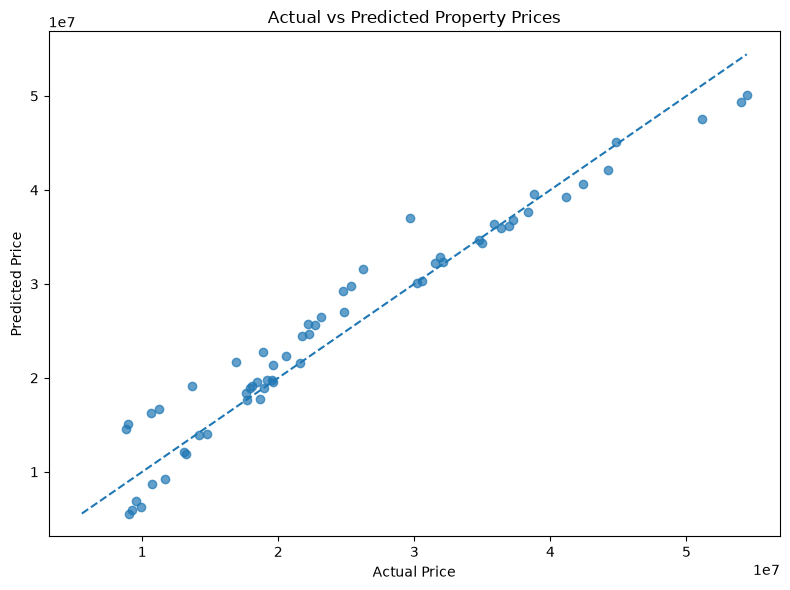

In [68]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test_prop, y_pred_prop, alpha=0.7)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Property Prices")

min_price = min(y_test_prop.min(), y_pred_prop.min())
max_price = max(y_test_prop.max(), y_pred_prop.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.tight_layout()
plt.show()

### Property Price Regression Results

A linear regression model was developed to predict property prices using
Area, Bedrooms, Bathrooms, Age, Location, and Property_Type.

Model Performance:
- MAE: 2,188,736.34
- RMSE: 2,907,633.21
- R²: 0.941

Interpretation:
The model achieved an R² of 0.941 on the test data, indicating that the
model explains approximately 94.1% of the variation in property prices
within this test set.

The MAE was 2,188,736.34, meaning that the average absolute difference
between the actual and predicted property prices was approximately
2.19 million price units.

The RMSE was 2,907,633.21. Because RMSE gives greater weight to larger
errors, its higher value indicates that some predictions have relatively
larger errors.

The results indicate that the selected property characteristics provide
substantial predictive information for property price in this dataset.

In [69]:
print(sales_df.columns.tolist())
print(sales_df.shape)
sales_df.head()

['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region', 'Total_Sales']
(100, 7)


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [70]:
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Date         100 non-null    str  
 1   Product      100 non-null    str  
 2   Quantity     100 non-null    int64
 3   Price        100 non-null    int64
 4   Customer_ID  100 non-null    str  
 5   Region       100 non-null    str  
 6   Total_Sales  100 non-null    int64
dtypes: int64(3), str(4)
memory usage: 8.3 KB


In [71]:
sales_df["Date"] = pd.to_datetime(sales_df["Date"])

print(sales_df.dtypes)
print(sales_df.head())

Date           datetime64[us]
Product                   str
Quantity                int64
Price                   int64
Customer_ID               str
Region                    str
Total_Sales             int64
dtype: object
        Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0 2024-01-01       Phone         7  37300     CUST001   East       261100
1 2024-01-02  Headphones         4  15406     CUST002  North        61624
2 2024-01-03       Phone         2  21746     CUST003   West        43492
3 2024-01-04  Headphones         1  30895     CUST004   East        30895
4 2024-01-05      Laptop         8  39835     CUST005  North       318680


In [72]:
total_sales = sales_df["Total_Sales"].sum()
total_quantity = sales_df["Quantity"].sum()
average_transaction = sales_df["Total_Sales"].mean()
average_price = sales_df["Price"].mean()

print("Sales Performance Summary")
print("-------------------------")
print(f"Total Sales       : {total_sales:,.2f}")
print(f"Total Quantity    : {total_quantity:,}")
print(f"Average Transaction Value : {average_transaction:,.2f}")
print(f"Average Product Price     : {average_price:,.2f}")

Sales Performance Summary
-------------------------
Total Sales       : 12,365,048.00
Total Quantity    : 478
Average Transaction Value : 123,650.48
Average Product Price     : 25,808.51


In [73]:
sales_by_product = (
    sales_df.groupby("Product")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("Sales by Product")
print("-----------------")
print(sales_by_product)

Sales by Product
-----------------
Product
Laptop        3889210
Tablet        2884340
Phone         2859394
Headphones    1384033
Monitor       1348071
Name: Total_Sales, dtype: int64


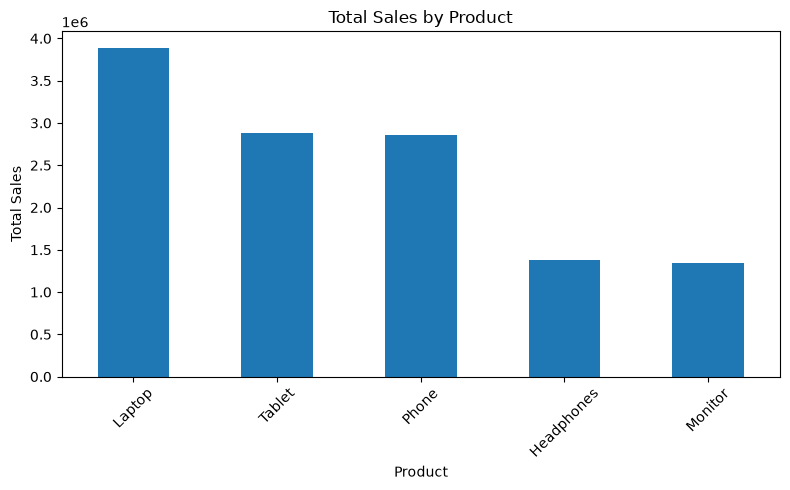

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sales_by_product.plot(kind="bar")

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [75]:
sales_by_region = (
    sales_df.groupby("Region")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("Sales by Region")
print("----------------")
print(sales_by_region)


Sales by Region
----------------
Region
North    3983635
South    3737852
East     2519639
West     2123922
Name: Total_Sales, dtype: int64


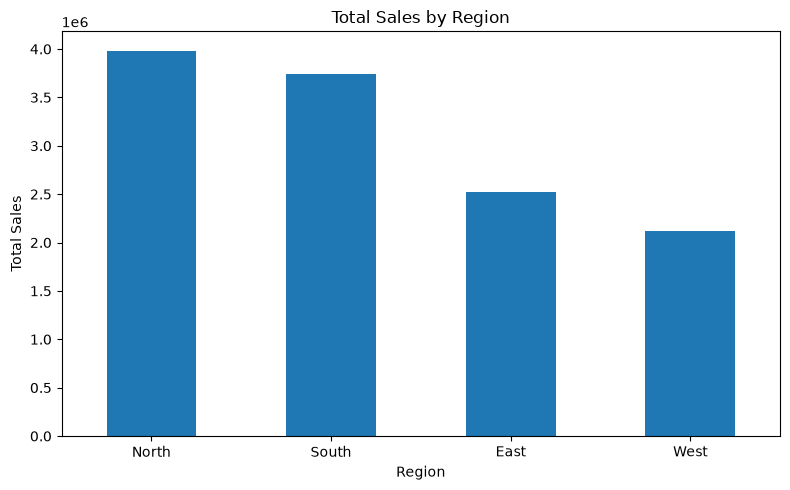

In [76]:
plt.figure(figsize=(8, 5))

sales_by_region.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [77]:
quantity_by_product = (
    sales_df.groupby("Product")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

print("Quantity Sold by Product")
print("------------------------")
print(quantity_by_product)

Quantity Sold by Product
------------------------
Product
Laptop        136
Tablet        127
Phone         101
Monitor        66
Headphones     48
Name: Quantity, dtype: int64


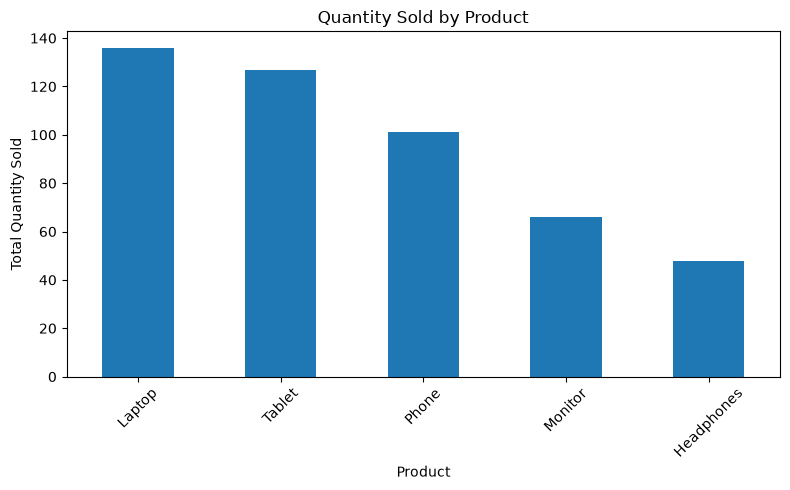

In [78]:
plt.figure(figsize=(8, 5))

quantity_by_product.plot(kind="bar")

plt.title("Quantity Sold by Product")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [79]:
avg_sales_by_region = (
    sales_df.groupby("Region")["Total_Sales"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Transaction Value by Region")
print("-----------------------------------")
print(avg_sales_by_region)

Average Transaction Value by Region
-----------------------------------
Region
North    142272.678571
South    138438.962963
East     132612.578947
West      81689.307692
Name: Total_Sales, dtype: float64


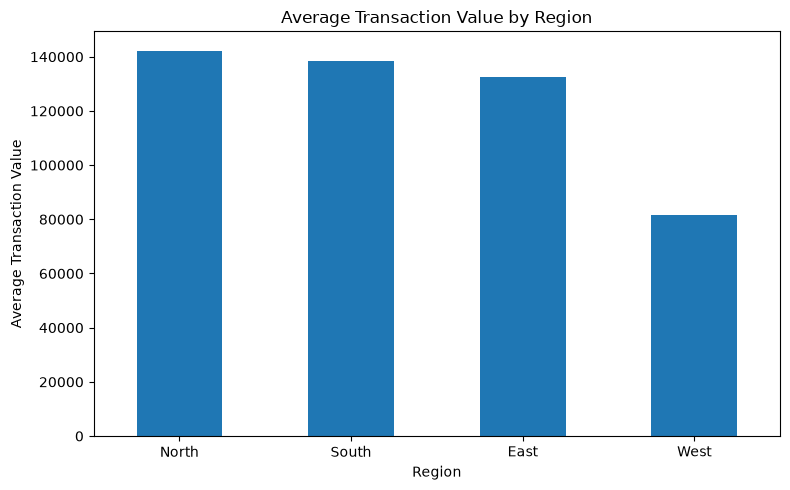

In [80]:
plt.figure(figsize=(8, 5))

avg_sales_by_region.plot(kind="bar")

plt.title("Average Transaction Value by Region")
plt.xlabel("Region")
plt.ylabel("Average Transaction Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [81]:
product_region_sales = pd.pivot_table(
    sales_df,
    values="Total_Sales",
    index="Product",
    columns="Region",
    aggfunc="sum"
)

print("Product × Region Sales")
print("----------------------")
print(product_region_sales)

Product × Region Sales
----------------------
Region        East    North    South    West
Product                                     
Headphones  288361   107091   512168  476413
Laptop      221946  1798206  1373120  495938
Monitor     642870   397100    39924  268177
Phone       506828   489284  1471428  391854
Tablet      859634  1191954   341212  491540


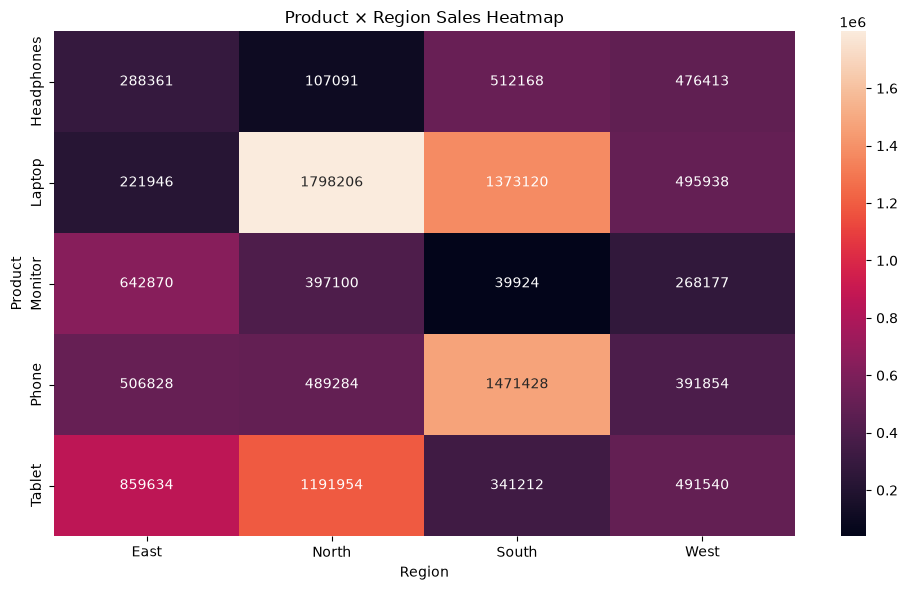

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.heatmap(
    product_region_sales,
    annot=True,
    fmt=".0f"
)

plt.title("Product × Region Sales Heatmap")
plt.xlabel("Region")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [83]:
sales_correlation = sales_df[
    ["Quantity", "Price", "Total_Sales"]
].corr()

print("Sales Correlation Matrix")
print("------------------------")
print(sales_correlation.round(3))

Sales Correlation Matrix
------------------------
             Quantity  Price  Total_Sales
Quantity        1.000  0.008        0.688
Price           0.008  1.000        0.646
Total_Sales     0.688  0.646        1.000


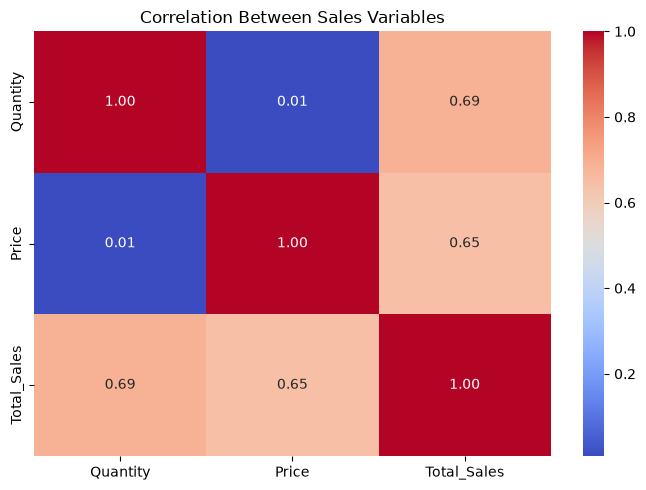

In [84]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    sales_correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Sales Variables")
plt.tight_layout()
plt.show()

In [85]:
from scipy.stats import f_oneway

east_sales = sales_df[sales_df["Region"] == "East"]["Total_Sales"]
north_sales = sales_df[sales_df["Region"] == "North"]["Total_Sales"]
south_sales = sales_df[sales_df["Region"] == "South"]["Total_Sales"]
west_sales = sales_df[sales_df["Region"] == "West"]["Total_Sales"]

f_statistic, p_value = f_oneway(
    east_sales,
    north_sales,
    south_sales,
    west_sales
)

print("One-Way ANOVA: Sales by Region")
print("--------------------------------")
print(f"F-statistic : {f_statistic:.3f}")
print(f"P-value    : {p_value:.3f}")

One-Way ANOVA: Sales by Region
--------------------------------
F-statistic : 2.164
P-value    : 0.097


### Sales Statistical Analysis

A one-way ANOVA test was conducted to examine whether average sales
differ significantly across the East, North, South, and West regions.

Hypotheses:
- H0: The mean sales are equal across all regions.
- H1: At least one region has a different mean sales value.

Results:
- F-statistic: 2.164
- P-value: 0.097
- Significance level (α): 0.05
- Decision: Fail to reject H0

Interpretation:
The p-value of 0.097 is greater than the significance level of 0.05.
Therefore, there is insufficient statistical evidence to conclude that
average sales differ significantly across the four regions.

Although the descriptive analysis may show differences in regional sales,
these observed differences are not statistically significant at the 5%
significance level in this dataset.

### Sales Analysis Insights

The sales analysis examined overall sales performance, product-level
performance, regional performance, transaction values, and relationships
between key numerical variables.

Key Findings:

1. Overall Sales Performance
The dataset was analyzed using total sales, total quantity sold,
average transaction value, and average product price to understand
overall business performance.

2. Product Performance
Sales were compared across products using total revenue and quantity
sold. The product-level analysis helps identify products that generate
higher revenue and products with higher sales volume.

3. Regional Performance
Total sales and average transaction values were compared across East,
North, South, and West regions. These comparisons provide a descriptive
view of regional business performance.

4. Product-Region Performance
A Product × Region heatmap was used to identify combinations of products
and regions with relatively higher or lower sales.

5. Correlation Analysis
Pearson correlation analysis was performed on Quantity, Price, and
Total_Sales to examine relationships between the numerical sales
variables.

6. Statistical Validation
A one-way ANOVA test was conducted to determine whether average sales
differ significantly across the four regions.

The ANOVA produced an F-statistic of 2.164 and a p-value of 0.097.
Since the p-value is greater than 0.05, the null hypothesis was not
rejected. Therefore, there is insufficient statistical evidence to
conclude that average sales differ significantly across the four
regions at the 5% significance level.

Business Implication:
Regional differences should be interpreted together with product-level,
transaction-level, and correlation results rather than relying only on
regional averages. Product performance and customer purchasing patterns
can be used to identify areas for further investigation and targeted
business actions.

# Overall Business Analysis Findings

This project analyzed three business areas using customer, property, and
sales datasets.

## 1. Customer Churn Analysis

The customer churn analysis examined customer tenure, monthly charges,
total charges, contract type, payment method, paperless billing, and
senior-citizen status.

A logistic regression model was developed to predict customer churn.

Model Performance:
- Accuracy: 93.0%
- Precision: 75.0%
- Recall: 54.5%
- F1 Score: 63.2%
- ROC-AUC: 0.982

The model demonstrated strong discrimination between churn and
non-churn customers. However, it missed 5 of the 11 actual churners in
the test set, indicating that additional investigation or threshold
tuning may be useful when the business objective is to identify more
potential churners.

## 2. Property Pricing Analysis

The property analysis examined Area, Bedrooms, Bathrooms, Age, Location,
and Property Type as factors related to property prices.

A linear regression model was developed to predict property prices.

Model Performance:
- MAE: 2,188,736.34
- RMSE: 2,907,633.21
- R²: 0.941

The model explained approximately 94.1% of the variation in property
prices within the test dataset. The results indicate that the selected
property characteristics provide substantial predictive information
for property prices in this dataset.

## 3. Sales Performance Analysis

The sales analysis examined total sales, quantity sold, product
performance, regional performance, average transaction value, and
product-region combinations.

Pearson correlation analysis was used to examine relationships between
Quantity, Price, and Total_Sales.

A one-way ANOVA test was also conducted to compare average sales across
East, North, South, and West regions.

ANOVA Results:
- F-statistic: 2.164
- P-value: 0.097
- Significance level: 0.05
- Decision: Fail to reject H0

The ANOVA result indicates that there is insufficient statistical
evidence to conclude that average sales differ significantly across
the four regions at the 5% significance level.

## Overall Conclusion

The project demonstrates how business data can be analyzed using
descriptive statistics, exploratory data analysis, statistical
hypothesis testing, correlation analysis, and machine learning.

The three modules provide complementary business perspectives:
customer retention, property pricing, and sales performance.

The findings can be used as a basis for further investigation,
targeted business actions, and ongoing performance monitoring.

# Business Recommendations

Based on the customer churn, property pricing, and sales performance
analyses, the following recommendations are proposed.

## 1. Customer Churn Reduction

The churn model achieved strong overall predictive performance, with an
ROC-AUC of 0.982. However, the model identified only 6 of the 11 actual
churners in the test set.

Recommendations:
- Develop an early-warning system for customers with high predicted
  churn probability.
- Prioritize retention campaigns for high-risk customers.
- Review contract and billing-related customer experiences.
- Consider targeted offers or loyalty incentives for customers at risk
  of leaving.
- Monitor churn prediction performance regularly and adjust the
  classification threshold if higher churn recall is required.

## 2. Property Pricing Strategy

The property price regression model achieved an R² of 0.941, showing
that the selected property characteristics provide substantial
information for estimating property prices.

Recommendations:
- Use data-driven price estimates as a reference when pricing properties.
- Consider property area, bedrooms, bathrooms, age, location, and
  property type when evaluating prices.
- Use predicted prices to identify potentially underpriced or overpriced
  properties for further review.
- Retrain the model periodically as new property transactions become
  available.

## 3. Sales Performance Improvement

The sales analysis examined product, region, quantity, transaction value,
and product-region performance.

Recommendations:
- Focus inventory and promotional activities on products with stronger
  sales performance.
- Investigate products with lower sales or lower quantities to identify
  potential pricing, marketing, or demand issues.
- Use product-region analysis to support regional sales planning.
- Monitor average transaction value to identify opportunities for
  increasing customer purchase value.
- Use correlation analysis to understand relationships among quantity,
  price, and total sales.

## 4. Regional Decision-Making

The one-way ANOVA produced a p-value of 0.097, which is greater than the
0.05 significance level.

Therefore, there is insufficient statistical evidence to conclude that
average sales differ significantly across the four regions.

Regional decisions should therefore not be based only on observed
differences in average sales. Product mix, customer behavior, pricing,
marketing activity, and transaction volume should also be considered.

# Implementation Plan

## Phase 1: Customer Retention

Timeline: Month 1

Actions:
- Calculate churn probability for active customers.
- Create high-, medium-, and low-risk customer segments.
- Launch targeted retention campaigns.
- Track monthly churn rate and campaign response.

Success Metrics:
- Reduction in monthly churn rate.
- Increase in customer retention rate.
- Improvement in recall of high-risk churn identification.

## Phase 2: Property Pricing

Timeline: Month 1–2

Actions:
- Integrate the regression model into the property evaluation process.
- Generate estimated prices for new properties.
- Compare model predictions with actual market prices.
- Monitor prediction errors and retrain the model when sufficient new
  data becomes available.

Success Metrics:
- Lower prediction error.
- Improved pricing consistency.
- Reduced number of significantly mispriced properties.

## Phase 3: Sales Optimization

Timeline: Month 2–3

Actions:
- Monitor product-level sales performance.
- Review product-region combinations.
- Adjust inventory based on demand patterns.
- Develop targeted promotions for selected products and regions.
- Monitor average transaction value.

Success Metrics:
- Increase in total sales.
- Increase in average transaction value.
- Improved product sales performance.
- Better inventory utilization.

## Phase 4: Continuous Monitoring

Timeline: Ongoing

Actions:
- Create monthly business performance dashboards.
- Track customer churn, property pricing accuracy, and sales KPIs.
- Compare actual results with model predictions.
- Retrain analytical models when business conditions or data patterns
  change.

Key KPIs:
- Customer churn rate
- Customer retention rate
- Churn prediction recall
- Property price prediction error
- Total sales
- Average transaction value
- Product sales
- Regional sales

In [86]:
import os

print("PROJECT FILES")
print("=============")

for root, dirs, files in os.walk("."):
    level = root.count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        if not file.startswith(".") and "checkpoint" not in root.lower():
            print(f"{indent}    {file}")

PROJECT FILES
./
    business_analysis.ipynb
    README.md
    requirements.txt
    .ipynb_checkpoints/
    data/
        cleaned_customer_churn.csv
        cleaned_property_data.csv
        cleaned_sales_data.csv
        customer_churn.csv
        house_prices.csv
        sales_data.csv
        .ipynb_checkpoints/
    report/
    visualizations/
        area_vs_price.png
        churn_by_contract.png
        customer_churn_distribution.png
        customer_correlation_heatmap.png
        monthly_charges_vs_churn.png
        price_by_property_type.png
        property_correlation_heatmap.png
        property_price_by_location.png
        sales_by_product.png
        sales_by_region.png
        tenure_vs_churn.png


In [87]:
print("========== SALES SUMMARY ==========")
print(f"Total Sales: {sales_df['Total_Sales'].sum():,.2f}")
print(f"Total Quantity: {sales_df['Quantity'].sum():,}")
print(f"Average Transaction Value: {sales_df['Total_Sales'].mean():,.2f}")
print(f"Average Product Price: {sales_df['Price'].mean():,.2f}")

print("\n========== SALES BY PRODUCT ==========")
print(sales_by_product)

print("\n========== SALES BY REGION ==========")
print(sales_by_region)

print("\n========== QUANTITY BY PRODUCT ==========")
print(quantity_by_product)

print("\n========== AVERAGE SALES BY REGION ==========")
print(avg_sales_by_region)

print("\n========== CORRELATION MATRIX ==========")
print(sales_correlation.round(3))

print("\n========== ANOVA ==========")
print(f"F-statistic: {f_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

========== SALES SUMMARY ==========
Total Sales: 12,365,048.00
Total Quantity: 478
Average Transaction Value: 123,650.48
Average Product Price: 25,808.51

========== SALES BY PRODUCT ==========
Product
Laptop        3889210
Tablet        2884340
Phone         2859394
Headphones    1384033
Monitor       1348071
Name: Total_Sales, dtype: int64

========== SALES BY REGION ==========
Region
North    3983635
South    3737852
East     2519639
West     2123922
Name: Total_Sales, dtype: int64

========== QUANTITY BY PRODUCT ==========
Product
Laptop        136
Tablet        127
Phone         101
Monitor        66
Headphones     48
Name: Quantity, dtype: int64

========== AVERAGE SALES BY REGION ==========
Region
North    142272.678571
South    138438.962963
East     132612.578947
West      81689.307692
Name: Total_Sales, dtype: float64

========== CORRELATION MATRIX ==========
             Quantity  Price  Total_Sales
Quantity        1.000  0.008        0.688
Price           0.008  1.000      